In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
acl_df = pd.read_csv("../data/processed/acl_analysis.csv")

In [21]:
acl_df.head()

,patient_id,injury,date_ami,level,score_pct,tsk_11
0,P0001,ACL,2023-01-19,1,90.0,28.0
1,P0001,ACL,2023-02-20,2,84.0,29.0
2,P0001,ACL,2023-03-16,2,87.0,28.0
3,P0001,ACL,2023-04-17,2,92.0,25.0
4,P0001,ACL,2023-05-15,complete,80.0,24.0


In [22]:
acl_df.shape

(415, 6)

In [23]:
acl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  415 non-null    str    
 1   injury      415 non-null    str    
 2   date_ami    415 non-null    str    
 3   level       415 non-null    str    
 4   score_pct   414 non-null    float64
 5   tsk_11      181 non-null    float64
dtypes: float64(2), str(4)
memory usage: 19.6 KB


In [24]:
acl_df.isna().sum()

patient_id      0
injury          0
date_ami        0
level           0
score_pct       1
tsk_11        234
dtype: int64

In [25]:
analysis_df = acl_df.dropna(subset=["score_pct", "tsk_11"]).copy()
analysis_df.shape

(180, 6)

In [26]:
analysis_df[["score_pct", "tsk_11"]].describe()

,score_pct,tsk_11
count,180.000000,180.000000
mean,75.177778,19.605556
std,10.181128,6.577851
min,35.000000,11.000000
25%,69.000000,14.000000
50%,75.000000,19.000000
75%,82.000000,25.000000
max,98.000000,42.000000


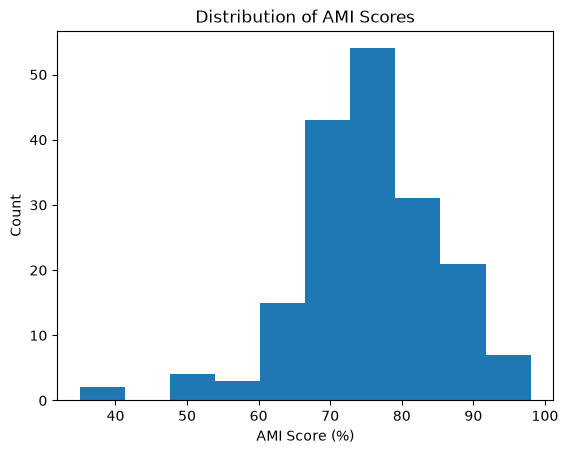

In [27]:
plt.hist(analysis_df["score_pct"])
plt.xlabel("AMI Score (%)")
plt.ylabel("Count")
plt.title("Distribution of AMI Scores")
plt.show()

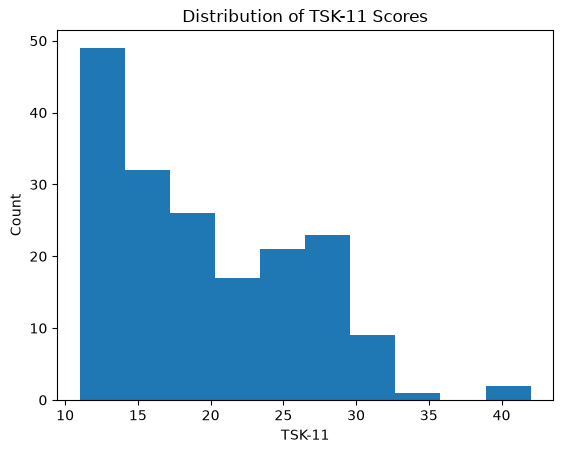

In [28]:
plt.hist(analysis_df["tsk_11"])
plt.xlabel("TSK-11")
plt.ylabel("Count")
plt.title("Distribution of TSK-11 Scores")
plt.show()

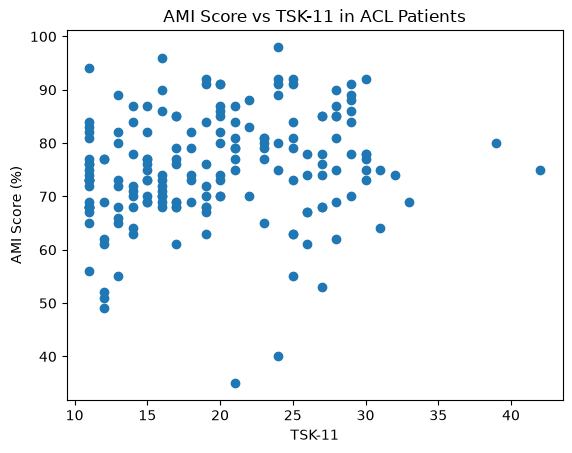

In [29]:
plt.scatter(analysis_df["tsk_11"], analysis_df["score_pct"])
plt.xlabel("TSK-11")
plt.ylabel("AMI Score (%)")
plt.title("AMI Score vs TSK-11 in ACL Patients")
plt.show()

In [30]:
analysis_df[["score_pct", "tsk_11"]].corr()

,score_pct,tsk_11
score_pct,1.000000,0.190081
tsk_11,0.190081,1.000000


## Findings

- A total of 180 ACL observations with complete AMI and TSK-11 data were analyzed.
- The mean AMI score was 75.18%.
- The mean TSK-11 score was 19.61.
- Visual inspection of the scatterplot suggested little evidence of a strong linear relationship between AMI score and TSK-11.
- Pearson correlation analysis showed a weak positive association (r = 0.19).